### py311_env - Python environment

In [57]:
!pip install -q deepeval

In [1]:
# load environment variable from .env file
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, LLMTestCaseParams, Turn, TurnParams, ConversationalTestCase

import pandas as pd
from deepeval.dataset import Golden

from deepeval.dataset import EvaluationDataset, Golden
from deepeval.metrics import AnswerRelevancyMetric, ConversationalGEval, ConversationCompletenessMetric, BiasMetric
from deepeval import evaluate


In [3]:
convo_geval_focus = ConversationalGEval(name="Focus", criteria = "Does the response directly address the specific question or task?")
convo_geval_helpful = ConversationalGEval(name="Helpful", criteria = "Does the response meaningfully help the user?")
convo_geval_completeness = ConversationalGEval(name="Completeness", criteria = "Does the response fully address the question without major omissions?")
convo_geval_voice = ConversationalGEval(name="Voice", criteria = "Does the response use clear, active voice?")
convo_geval_engagement = ConversationalGEval(name="Engagement", criteria = "Does the response use appropriate and engaging language?")

convo_completeness = ConversationCompletenessMetric()

In [4]:
import pandas as pd
data = pd.read_csv("data_bank/hard.csv")
data_sel = data.dropna(subset=['tursio_response']).reset_index(drop=True)   
data_sel.head()

,persona,kpi,difficulty,synthetic_questions,tursio_response
0,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,What is the trend of 90+ DPD accounts segmente...,"Key Insights\n\nOver the last 24 months, the 9..."
1,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,For accounts that became delinquent in the las...,"High-Impact Findings\n\nIn the last year, 100%..."
2,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,Analyze the concentration risk by identifying ...,Key Insights:\n\nThe top 10% of borrowers driv...
3,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,What behavioral traits or transaction patterns...,Great question but unfortunately no data point...
4,Risk & Credit Analytics Manager; CRO; Complian...,90+ DPD Rate; Delinquency Ratio; Non-Performin...,hard,How does the delinquency ratio differ across d...,Key Findings:\n\nWide Range of Delinquency Rat...


In [5]:
turns = []
for idx, row in data_sel.iterrows():
    turn_user = Turn(role="user", retrieval_context=[f"user persona: {row['persona']}", f"KPI : {row['kpi']}"]  ,content=row["synthetic_questions"])   
    turn_assistant = Turn(role="assistant", content=row["tursio_response"])
    convo_test_case = ConversationalTestCase(turns=[turn_user, turn_assistant])

    turns.append(convo_test_case)

print (f"Added test cases for {len(turns)}")

Added test cases for 38


In [6]:
turns[0]

ConversationalTestCase(turns=[Turn(role='user', content='What is the trend of 90+ DPD accounts segmented by loan type over the last 24 months, and how does it correlate with macroeconomic indicators such as unemployment and interest rates?', retrieval_context=['user persona: Risk & Credit Analytics Manager; CRO; Compliance Officer', 'KPI : 90+ DPD Rate; Delinquency Ratio; Non-Performing Loan %']), Turn(role='assistant', content='Key Insights\n\nOver the last 24 months, the 90+ DPD counts show monthly fluctuations across loan types with certain loan types (e.g., 101 and 102) exhibiting larger swings in both counts and loan volumes.\nWhile the dataset provides monthly average interest rates alongside DPD counts, there is no clear, direct correlation between the interest rate changes and the frequency of 90+ DPD accounts. The macroeconomic indicator of unemployment is not present in the data, so its correlation cannot be assessed.')], scenario=None, context=None, name=None, user_descripti

In [7]:
import time
import os
from deepeval.evaluate import AsyncConfig

import sys
from io import StringIO
import contextlib


# Increase timeout for API calls
os.environ["DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"] = "600"
os.environ["DEEPEVAL_VERBOSE"] = "false"

# Configure async evaluation with delays to avoid rate limits
async_config = AsyncConfig(
    run_async=False,  # Run synchronously to add delays
)

all_results = []
batch_size = 2  # Reduced from 5 to 2 test cases per batch

for step in range(0, len(turns), batch_size):
    # Evaluate with delay between API calls
    print(f"Evaluating test cases {step} to {min(step + batch_size, len(convo_test_case.turns))}")
    
    test_batch = turns[step:step + batch_size]
    
    try:
        with contextlib.redirect_stdout(StringIO()), contextlib.redirect_stderr(StringIO()):

            results = evaluate(
                test_cases=test_batch,
                metrics=[convo_geval_focus
                        , convo_geval_completeness
                        , convo_geval_engagement
                        , convo_geval_helpful
                        , convo_geval_voice
                        , convo_completeness],
                async_config=async_config,
            )
        for res in results.test_results:
            all_results.append(res)
    except Exception as e:
        print(f"Error evaluating batch at {step}: {e}")
        continue

    # Add delay to avoid rate limiting
    time.sleep(3)

print(f"Evaluated {len(all_results)} test cases")


✨ You're running DeepEval's latest Focus [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Completeness [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Engagement [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Helpful [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Voice [Conversational GEval] Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

...

✨ You're running DeepEval's latest Conversation Completeness Metric! (using gpt-4.1, strict=False, 
async_mode=False)...

Evaluating test cases 36 to 2


⚠ WARNING: No hyperparameters logged.
» ]8;id=372449;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 37.13s | token cost: 0.028074 USD)
» Test Results (2 total tests):
   » Pass Rate: 50.0% | Passed: 1 | Failed: 1

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Evaluated 38 test cases


In [8]:
all_results[0].metrics_data

[MetricData(name='Focus [Conversational GEval]', threshold=0.5, success=True, score=0.9, reason="The assistant directly addresses the user's request by summarizing the trend of 90+ DPD accounts by loan type over 24 months and discussing the available macroeconomic indicators. It notes the absence of unemployment data, which is relevant and transparent. The response is appropriate, relevant, and consistent with the user's query, but could be slightly improved by providing more specific quantitative details or visual trends if available.", strict_mode=False, evaluation_model='gpt-4.1', error=None, evaluation_cost=0.0028199999999999996, verbose_logs='Criteria:\nDoes the response directly address the specific question or task? \n \nEvaluation Steps:\n[\n    "For each turn, identify the Role (user or chatbot) and the Content provided.",\n    "Check if the chatbot\'s Content directly addresses the specific question or task posed by the user\'s Content in the previous turn.",\n    "Evaluate i

In [9]:
import pandas as pd

data_for_df = []

for test_result in all_results: #results.test_results:
    for m in test_result.metrics_data:
        row = {
            'name': test_result.name,
            'input': test_result.input,
            'actual_output': test_result.actual_output,
            'expected_output': test_result.expected_output,
            'turns': test_result.turns,
            'test_success': test_result.success
        }

    # if test_result.metrics_data:
     
        # Assuming one metric per test case for simplicity based on previous output
        metric_data = m #test_result.metrics_data[0]
        row['metric_name'] = metric_data.name
        row['metric_score'] = metric_data.score
        row['metric_threshold'] = metric_data.threshold
        row['metric_success'] = metric_data.success
        row['metric_reason'] = metric_data.reason
    # else:
    #     row['metric_name'] = None
    #     row['metric_score'] = None
    #     row['metric_threshold'] = None
    #     row['metric_success'] = None
    #     row['metric_reason'] = None

        data_for_df.append(row)

df_results = pd.DataFrame(data_for_df)
display(df_results.head())

,name,input,actual_output,expected_output,turns,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason
0,conversational_test_case_0,None,None,None,[role='user' content='What is the trend of 90+...,False,Focus [Conversational GEval],0.900000,0.5,True,The assistant directly addresses the user's re...
1,conversational_test_case_0,None,None,None,[role='user' content='What is the trend of 90+...,False,Completeness [Conversational GEval],0.793991,0.5,True,The assistant correctly identifies trends in 9...
2,conversational_test_case_0,None,None,None,[role='user' content='What is the trend of 90+...,False,Engagement [Conversational GEval],0.826894,0.5,True,"The assistant uses clear, professional languag..."
3,conversational_test_case_0,None,None,None,[role='user' content='What is the trend of 90+...,False,Helpful [Conversational GEval],0.822270,0.5,True,The assistant directly addresses the user's qu...
4,conversational_test_case_0,None,None,None,[role='user' content='What is the trend of 90+...,False,Voice [Conversational GEval],0.896267,0.5,True,"The assistant's response uses clear, active vo..."


In [10]:
df_results.shape

(228, 11)

In [11]:
df_results.to_csv("deepeval_tursio_results_hard_convo.csv", index=False)

In [12]:
df_results.metric_name.unique()

array(['Focus [Conversational GEval]',
       'Completeness [Conversational GEval]',
       'Engagement [Conversational GEval]',
       'Helpful [Conversational GEval]', 'Voice [Conversational GEval]',
       'Conversation Completeness'], dtype=object)

In [13]:
df_results[df_results['metric_success'] == False].groupby(["metric_name"])["name"].count()

metric_name
Completeness [Conversational GEval]     8
Conversation Completeness              18
Engagement [Conversational GEval]       5
Focus [Conversational GEval]            5
Helpful [Conversational GEval]          6
Name: name, dtype: int64

In [14]:
df_results[df_results['metric_success'] == False]["metric_reason"].values

array(["The score is 0.0 because the LLM response did not fully address the user's intention to analyze the correlation between overdue loan accounts and all requested macroeconomic indicators over the past 24 months. Specifically, the LLM failed to provide any analysis or data regarding unemployment, simply stating its absence, which left the user's request unmet.",
       "The score is 0.0 because the LLM response only provided descriptive statistics about payment history length and did not analyze or discuss how payment history length impacts future default likelihood, which was the core of the User's intention.",
       "The assistant correctly identifies its inability to answer due to lack of data, which is relevant and appropriate. However, it does not attempt to address the user's question based on general knowledge or typical patterns, nor does it provide any partial insights or clarifications. This results in only a partial fulfillment of directly addressing the user's request

In [15]:
df_results[df_results['metric_score'] <1]["metric_reason"].values

array(["The assistant directly addresses the user's request by summarizing the trend of 90+ DPD accounts by loan type over 24 months and discussing the available macroeconomic indicators. It notes the absence of unemployment data, which is relevant and transparent. The response is appropriate, relevant, and consistent with the user's query, but could be slightly improved by providing more specific quantitative details or visual trends if available.",
       "The assistant correctly identifies trends in 90+ DPD accounts by loan type and addresses the correlation with interest rates, noting the lack of clear correlation. It also appropriately states that unemployment data is not available, thus cannot be analyzed. The response is appropriate for the assistant's role and fully addresses the user's question given the data constraints. However, the explanation could be more detailed regarding the specific trends by loan type and provide more quantitative insights if available.",
       "The

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

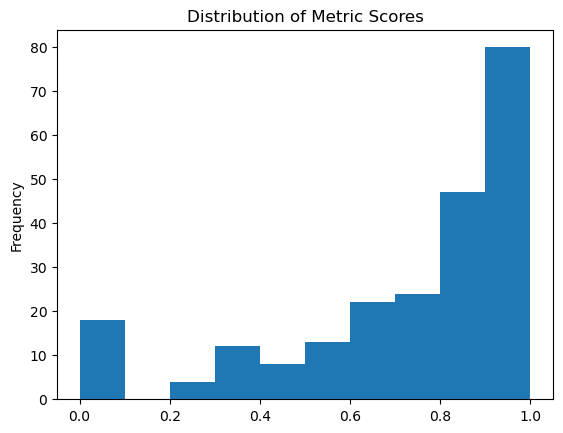

In [16]:
df_results.metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')